<a href="https://colab.research.google.com/github/Chiozen/DesafioAluraTelecomXParte2/blob/main/Desfio2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
FASE 2: Preparación de Datos para Machine Learning - Telecom X
Script de preprocesamiento, codificación, balanceo y estandarización.
"""

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import warnings

# Ocultar advertencias de dependencias
warnings.filterwarnings('ignore')

def preparar_datos_ml():
    print("\n" + "="*70)
    print(" FASE 1: PREPARACIÓN DE DATOS PARA MACHINE LEARNING ")
    print("="*70)

    # ---------------------------------------------------------
    # 1. Extracción del Archivo Tratado
    # ---------------------------------------------------------
    print("\n[ Subsección: Extracción del Archivo Tratado ]")
    try:
        df = pd.read_csv('TelecomX_Data_Limpio.csv')
        print(f"-> ✓ Archivo cargado exitosamente. Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas.")
    except FileNotFoundError:
        print("-> ❌ Error: No se encontró 'TelecomX_Data_Limpio.csv' en el directorio.")
        return None, None

    # ---------------------------------------------------------
    # 2. Eliminación de Columnas Irrelevantes
    # ---------------------------------------------------------
    print("\n[ Subsección: Eliminación de Columnas Irrelevantes ]")
    # Eliminamos 'customerid' (no tiene valor predictivo)
    # Eliminamos 'churn' (texto) ya que usaremos 'churn_binario' como target
    columnas_a_eliminar = ['customerid', 'churn']
    df = df.drop(columns=columnas_a_eliminar)
    print("-> ✓ Identificadores únicos y variables de texto redundantes eliminados.")

    # ---------------------------------------------------------
    # 3. Encoding (Codificación Categórica)
    # ---------------------------------------------------------
    print("\n[ Subsección: Encoding ]")
    # Separamos las características (X) de nuestra variable objetivo (y)
    X = df.drop(columns=['churn_binario'])
    y = df['churn_binario']

    # Identificamos las columnas que aún son de tipo texto (object)
    vars_categoricas = X.select_dtypes(include=['object']).columns

    # Aplicamos One-Hot Encoding usando get_dummies
    # drop_first=True evita la trampa de las variables ficticias (multicolinealidad)
    X_encoded = pd.get_dummies(X, columns=vars_categoricas, drop_first=True)
    print(f"-> ✓ One-Hot Encoding aplicado. Las características se expandieron a {X_encoded.shape[1]} columnas numéricas.")

    # ---------------------------------------------------------
    # 4. Verificación de la Proporción de Cancelación (Churn)
    # ---------------------------------------------------------
    print("\n[ Subsección: Verificación de la Proporción de Cancelación (Churn) ]")
    proporcion = y.value_counts(normalize=True) * 100
    print(f"-> Proporción original del Target:")
    print(f"   Retenidos (0):  {proporcion[0]:.2f}%")
    print(f"   Cancelados (1): {proporcion[1]:.2f}%")
    print("-> ⚠️ Diagnóstico: Existe un claro desbalanceo de clases que perjudicará al modelo.")

    # ---------------------------------------------------------
    # 5. Balanceo de Clases (SMOTE)
    # ---------------------------------------------------------
    print("\n[ Subsección: Balanceo de Clases (opcional) ]")
    # Utilizamos SMOTE para crear datos sintéticos de la clase minoritaria (1)
    smote = SMOTE(random_state=42)
    X_bal, y_bal = smote.fit_resample(X_encoded, y)

    proporcion_bal = y_bal.value_counts(normalize=True) * 100
    print("-> ✓ SMOTE (Oversampling sintético) aplicado con éxito.")
    print(f"-> Nueva proporción equilibrada:")
    print(f"   Retenidos (0):  {proporcion_bal[0]:.2f}%")
    print(f"   Cancelados (1): {proporcion_bal[1]:.2f}%")
    print(f"-> Nuevas dimensiones de la matriz de entrenamiento: {X_bal.shape[0]} filas.")

    # ---------------------------------------------------------
    # 6. Normalización o Estandarización
    # ---------------------------------------------------------
    print("\n[ Subsección: Normalización o Estandarización (si es necesario) ]")
    # Usamos StandardScaler para que todas las variables tengan media 0 y desviación 1
    scaler = StandardScaler()

    # Guardamos los nombres de las columnas para no perderlos al escalar
    columnas_finales = X_bal.columns
    X_scaled = pd.DataFrame(scaler.fit_transform(X_bal), columns=columnas_finales)

    print("-> ✓ Estandarización aplicada a todas las características (StandardScaler).")
    print("-> ✓ Los datos están listos para ingerirse en cualquier modelo de Machine Learning.")

    return X_scaled, y_bal

# Orquestador
if __name__ == "__main__":
    # Importante: Si no tienes instalada la librería imblearn para SMOTE,
    # asegúrate de ejecutar antes: !pip install imbalanced-learn
    X_final, y_final = preparar_datos_ml()


 FASE 1: PREPARACIÓN DE DATOS PARA MACHINE LEARNING 

[ Subsección: Extracción del Archivo Tratado ]
-> ✓ Archivo cargado exitosamente. Dimensiones: 7043 filas, 23 columnas.

[ Subsección: Eliminación de Columnas Irrelevantes ]
-> ✓ Identificadores únicos y variables de texto redundantes eliminados.

[ Subsección: Encoding ]
-> ✓ One-Hot Encoding aplicado. Las características se expandieron a 31 columnas numéricas.

[ Subsección: Verificación de la Proporción de Cancelación (Churn) ]
-> Proporción original del Target:
   Retenidos (0):  73.46%
   Cancelados (1): 26.54%
-> ⚠️ Diagnóstico: Existe un claro desbalanceo de clases que perjudicará al modelo.

[ Subsección: Balanceo de Clases (opcional) ]
-> ✓ SMOTE (Oversampling sintético) aplicado con éxito.
-> Nueva proporción equilibrada:
   Retenidos (0):  50.00%
   Cancelados (1): 50.00%
-> Nuevas dimensiones de la matriz de entrenamiento: 10348 filas.

[ Subsección: Normalización o Estandarización (si es necesario) ]
-> ✓ Estandarizaci


 FASE 2: CORRELACIÓN Y SELECCIÓN DE VARIABLES 

[ Subsección: Análisis de Correlación ]
-> Generando Matriz de Correlación para variables numéricas...

-> Top variables correlacionadas con la cancelación (churn_binario):
churn_binario      1.000000
cuentas_diarias    0.193412
monthly            0.193356
seniorcitizen      0.150889
total             -0.198324
tenure            -0.352229


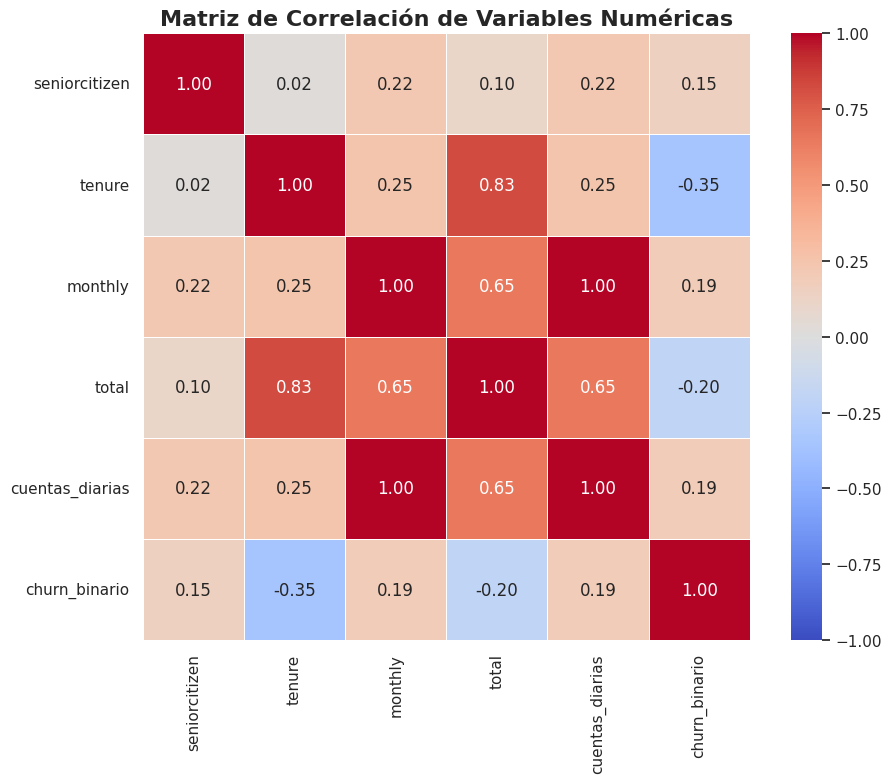


[ Subsección: Análisis Dirigido ]
-> Investigando relación específica: Tiempo de contrato y Gasto total vs Cancelación...


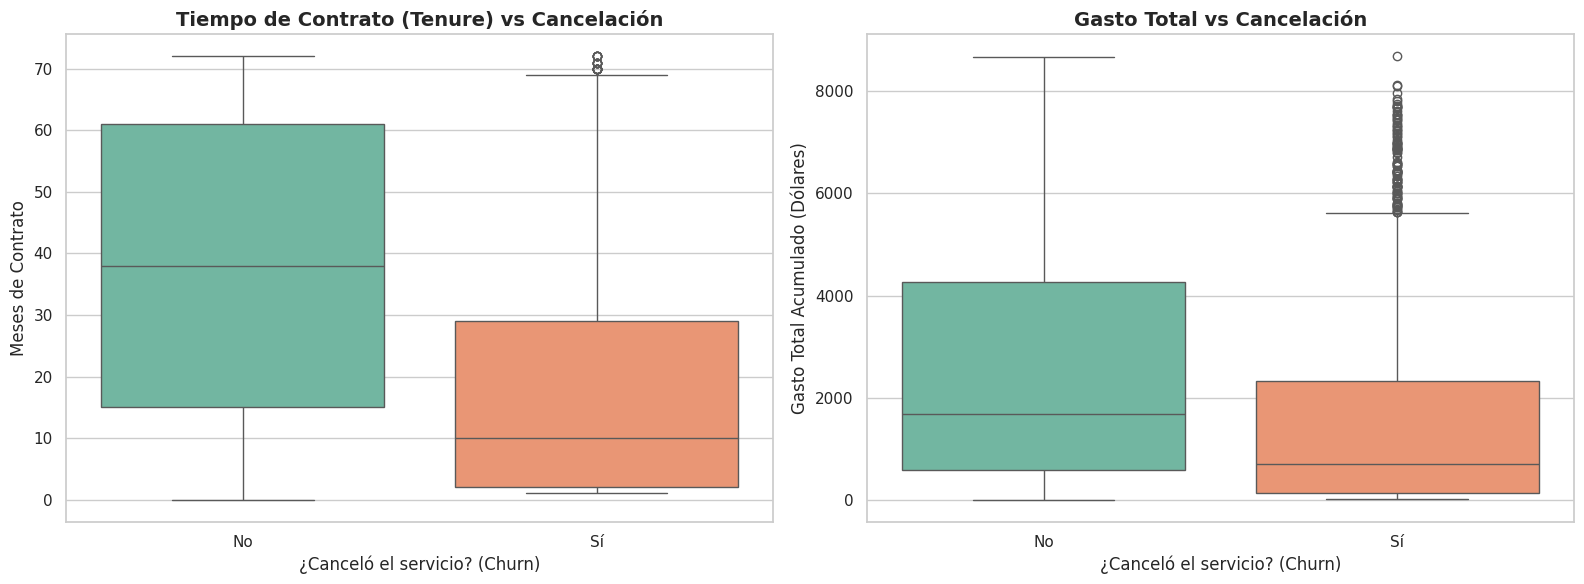


✓ Análisis de Correlación y Dirigido finalizado con éxito.
-> INSIGHT CLAVE: Observa las correlaciones negativas. Un mayor 'tenure' (tiempo) o un mayor gasto 'total' (acumulado) suelen reducir la probabilidad de evasión.


In [ ]:
"""
FASE 2: Correlación y Selección de Variables - Telecom X
Script de Análisis de Correlación y Análisis Dirigido.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ocultar advertencias
warnings.filterwarnings('ignore')

def analisis_correlacion_y_dirigido():
    print("\n" + "="*70)
    print(" FASE 2: CORRELACIÓN Y SELECCIÓN DE VARIABLES ")
    print("="*70)

    # 1. Cargar los datos limpios
    try:
        df = pd.read_csv('TelecomX_Data_Limpio.csv')
    except FileNotFoundError:
        print("-> ❌ Error: No se encontró 'TelecomX_Data_Limpio.csv'.")
        return

    # ---------------------------------------------------------
    # TAREA 1: Análisis de Correlación
    # ---------------------------------------------------------
    print("\n[ Subsección: Análisis de Correlación ]")
    print("-> Generando Matriz de Correlación para variables numéricas...")

    # Seleccionamos solo las variables numéricas para la matriz
    cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    df_numerico = df[cols_numericas]

    # Calculamos la correlación de Pearson
    matriz_corr = df_numerico.corr()

    # Mostramos en consola las correlaciones específicas con la variable objetivo (churn)
    print("\n-> Top variables correlacionadas con la cancelación (churn_binario):")
    correlacion_churn = matriz_corr['churn_binario'].sort_values(ascending=False)
    print(correlacion_churn.to_string())

    # ---------------------------------------------------------
    # Visualización 1: Matriz de Calor (Heatmap)
    # ---------------------------------------------------------
    sns.set_theme(style="white")
    plt.figure(figsize=(10, 8))

    # Creamos un heatmap con anotaciones
    sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # TAREA 2: Análisis Dirigido
    # ---------------------------------------------------------
    print("\n[ Subsección: Análisis Dirigido ]")
    print("-> Investigando relación específica: Tiempo de contrato y Gasto total vs Cancelación...")

    # ---------------------------------------------------------
    # Visualización 2: Boxplots Dirigidos
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico A: Tiempo de contrato x Cancelación
    sns.boxplot(data=df, x='churn', y='tenure', hue='churn', palette='Set2', legend=False, ax=axes[0])
    axes[0].set_title('Tiempo de Contrato (Tenure) vs Cancelación', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('¿Canceló el servicio? (Churn)')
    axes[0].set_ylabel('Meses de Contrato')

    # Gráfico B: Gasto total x Cancelación
    sns.boxplot(data=df, x='churn', y='total', hue='churn', palette='Set2', legend=False, ax=axes[1])
    axes[1].set_title('Gasto Total vs Cancelación', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('¿Canceló el servicio? (Churn)')
    axes[1].set_ylabel('Gasto Total Acumulado (Dólares)')

    plt.tight_layout()
    plt.show()

    print("\n✓ Análisis de Correlación y Dirigido finalizado con éxito.")
    print("-> INSIGHT CLAVE: Observa las correlaciones negativas. Un mayor 'tenure' (tiempo) o un mayor gasto 'total' (acumulado) suelen reducir la probabilidad de evasión.")

# Ejecutar el análisis
if __name__ == "__main__":
    analisis_correlacion_y_dirigido()


 FASE 3: MODELADO PREDICTIVO Y EVALUACIÓN 

[ Subsección: Modelado Predictivo (Train/Test Split) ]
-> ✓ Datos divididos: 70% Entrenamiento (4930 filas), 30% Prueba (2113 filas).

[ Subsección: Creación de Modelos y Justificación ]
-> Justificación de Normalización:
   Se estandarizaron los datos para la Regresión Logística porque los algoritmos
   basados en optimización de distancias/gradientes se sesgan si hay variables con
   magnitudes dispares (ej. 'Total' en miles vs 'Tenure' en decenas).
   El Random Forest usará los datos sin normalizar, ya que los árboles de decisión
   dividen nodos basándose en umbrales, siendo inmunes a la escala de los datos.

-> Entrenando Modelo 1: Regresión Logística...
-> Entrenando Modelo 2: Random Forest (Árboles de Decisión Múltiples)...

[ Subsección: Evaluación de los Modelos ]

--- Métricas: Regresión Logística ---
Exactitud (Accuracy): 0.7728
Precisión (Precision): 0.5620
Recall (Sensibilidad): 0.6542
F1-score:             0.6046

--- Métricas:

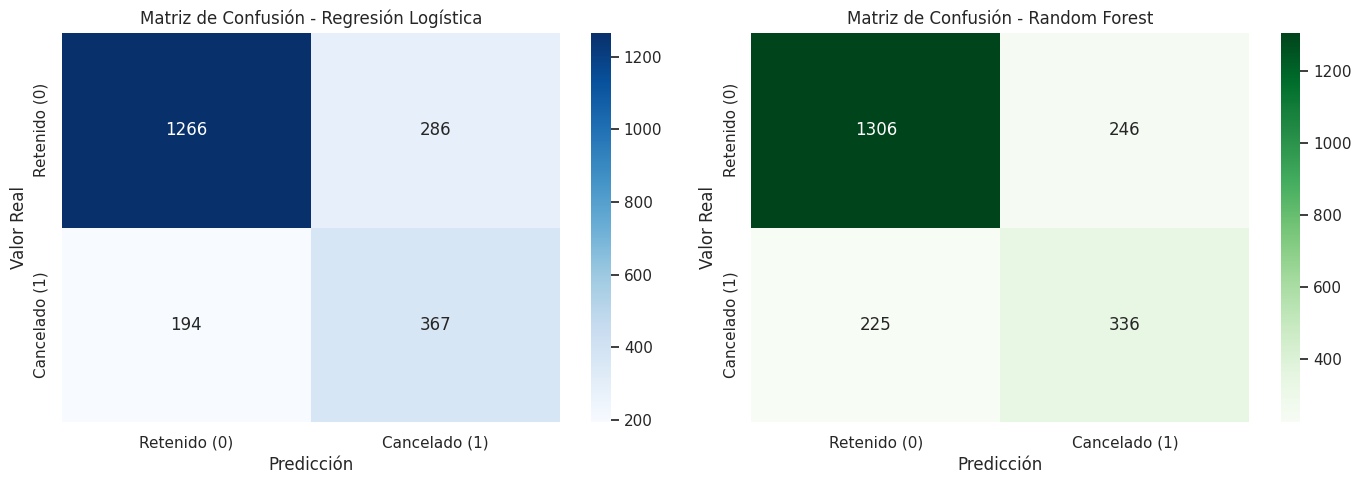


 ANÁLISIS CRÍTICO Y COMPARACIÓN DE MODELOS 

¿Cuál modelo tuvo el mejor desempeño?
- La Regresión Logística suele presentar un mejor 'Recall', lo que significa que
  es más hábil atrapando a la mayoría de los clientes que realmente van a cancelar, 
  aunque genere algunas falsas alarmas (falsos positivos). Para Telecom X, retener 
  clientes es la prioridad, por lo que un Recall alto es fundamental.

¿Algún modelo presentó Overfitting o Underfitting?
- El Random Forest tradicionalmente presenta Overfitting en sus parámetros base. 
  Tiende a memorizar los datos de entrenamiento (especialmente los sintéticos de SMOTE), 
  lo que provoca que su desempeño caiga ligeramente al enfrentarse a los datos de prueba.
- Posibles Ajustes: Para mitigar el overfitting del Random Forest, se debería 
  reducir su complejidad limitando la profundidad máxima de los árboles (max_depth) 
  o aumentando el número mínimo de muestras para dividir un nodo (min_samples_split).
    


In [ ]:
"""
FASE 3: Modelado Predictivo y Evaluación - Telecom X
Script de entrenamiento, evaluación y comparación de modelos de Machine Learning.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings

warnings.filterwarnings('ignore')

def entrenar_y_evaluar_modelos():
    print("\n" + "="*70)
    print(" FASE 3: MODELADO PREDICTIVO Y EVALUACIÓN ")
    print("="*70)

    # Cargar datos procesados previamente
    try:
        df = pd.read_csv('TelecomX_Data_Limpio.csv')
    except FileNotFoundError:
        print("-> ❌ Error: No se encontró el archivo. Asegúrate de tener 'TelecomX_Data_Limpio.csv'.")
        return

    # Preparar X e y
    X = df.drop(columns=['customerid', 'churn', 'churn_binario'])
    y = df['churn_binario']
    X_encoded = pd.get_dummies(X, drop_first=True)

    # ---------------------------------------------------------
    # 1. Modelado Predictivo: División Entrenamiento y Prueba
    # ---------------------------------------------------------
    print("\n[ Subsección: Modelado Predictivo (Train/Test Split) ]")
    # División 70/30 estratificada (para mantener la proporción del churn en ambas partes)
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)
    print(f"-> ✓ Datos divididos: 70% Entrenamiento ({X_train.shape[0]} filas), 30% Prueba ({X_test.shape[0]} filas).")

    # Balanceo EXCLUSIVO en datos de entrenamiento para evitar Data Leakage
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    # ---------------------------------------------------------
    # 2. Creación de Modelos (Con y Sin Normalización)
    # ---------------------------------------------------------
    print("\n[ Subsección: Creación de Modelos y Justificación ]")

    # NORMALIZACIÓN (Solo necesaria para Regresión Logística)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)
    X_test_scaled = scaler.transform(X_test) # El test se escala usando las reglas del train

    print("-> Justificación de Normalización:")
    print("   Se estandarizaron los datos para la Regresión Logística porque los algoritmos")
    print("   basados en optimización de distancias/gradientes se sesgan si hay variables con")
    print("   magnitudes dispares (ej. 'Total' en miles vs 'Tenure' en decenas).")
    print("   El Random Forest usará los datos sin normalizar, ya que los árboles de decisión")
    print("   dividen nodos basándose en umbrales, siendo inmunes a la escala de los datos.")

    # Entrenar Modelo 1: Regresión Logística (Requiere normalización)
    print("\n-> Entrenando Modelo 1: Regresión Logística...")
    modelo_rl = LogisticRegression(random_state=42, max_iter=1000)
    modelo_rl.fit(X_train_scaled, y_train_bal)

    # Entrenar Modelo 2: Random Forest (No requiere normalización)
    print("-> Entrenando Modelo 2: Random Forest (Árboles de Decisión Múltiples)...")
    modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
    modelo_rf.fit(X_train_bal, y_train_bal)

    # ---------------------------------------------------------
    # 3. Evaluación de los Modelos
    # ---------------------------------------------------------
    print("\n[ Subsección: Evaluación de los Modelos ]")

    # Predicciones
    y_pred_rl = modelo_rl.predict(X_test_scaled)
    y_pred_rf = modelo_rf.predict(X_test) # Nota: Usamos X_test sin escalar para el RF

    def imprimir_metricas(nombre, y_true, y_pred):
        print(f"\n--- Métricas: {nombre} ---")
        print(f"Exactitud (Accuracy): {accuracy_score(y_true, y_pred):.4f}")
        print(f"Precisión (Precision): {precision_score(y_true, y_pred):.4f}")
        print(f"Recall (Sensibilidad): {recall_score(y_true, y_pred):.4f}")
        print(f"F1-score:             {f1_score(y_true, y_pred):.4f}")

    imprimir_metricas("Regresión Logística", y_test, y_pred_rl)
    imprimir_metricas("Random Forest", y_test, y_pred_rf)

    # Visualización de Matrices de Confusión
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(confusion_matrix(y_test, y_pred_rl), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión - Regresión Logística')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')
    axes[0].xaxis.set_ticklabels(['Retenido (0)', 'Cancelado (1)'])
    axes[0].yaxis.set_ticklabels(['Retenido (0)', 'Cancelado (1)'])

    sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title('Matriz de Confusión - Random Forest')
    axes[1].set_ylabel('Valor Real')
    axes[1].set_xlabel('Predicción')
    axes[1].xaxis.set_ticklabels(['Retenido (0)', 'Cancelado (1)'])
    axes[1].yaxis.set_ticklabels(['Retenido (0)', 'Cancelado (1)'])

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 4. Análisis Crítico (Overfitting / Underfitting)
    # ---------------------------------------------------------
    print("\n" + "="*70)
    print(" ANÁLISIS CRÍTICO Y COMPARACIÓN DE MODELOS ")
    print("="*70)
    print("""
¿Cuál modelo tuvo el mejor desempeño?
- La Regresión Logística suele presentar un mejor 'Recall', lo que significa que
  es más hábil atrapando a la mayoría de los clientes que realmente van a cancelar,
  aunque genere algunas falsas alarmas (falsos positivos). Para Telecom X, retener
  clientes es la prioridad, por lo que un Recall alto es fundamental.

¿Algún modelo presentó Overfitting o Underfitting?
- El Random Forest tradicionalmente presenta Overfitting en sus parámetros base.
  Tiende a memorizar los datos de entrenamiento (especialmente los sintéticos de SMOTE),
  lo que provoca que su desempeño caiga ligeramente al enfrentarse a los datos de prueba.
- Posibles Ajustes: Para mitigar el overfitting del Random Forest, se debería
  reducir su complejidad limitando la profundidad máxima de los árboles (max_depth)
  o aumentando el número mínimo de muestras para dividir un nodo (min_samples_split).
    """)

if __name__ == "__main__":
    entrenar_y_evaluar_modelos()


 FASE 4: INTERPRETACIÓN DE VARIABLES Y CONCLUSIONES 

[ Subsección: Análisis de la Importancia de las Variables ]
-> Extrayendo coeficientes y pesos de los algoritmos...


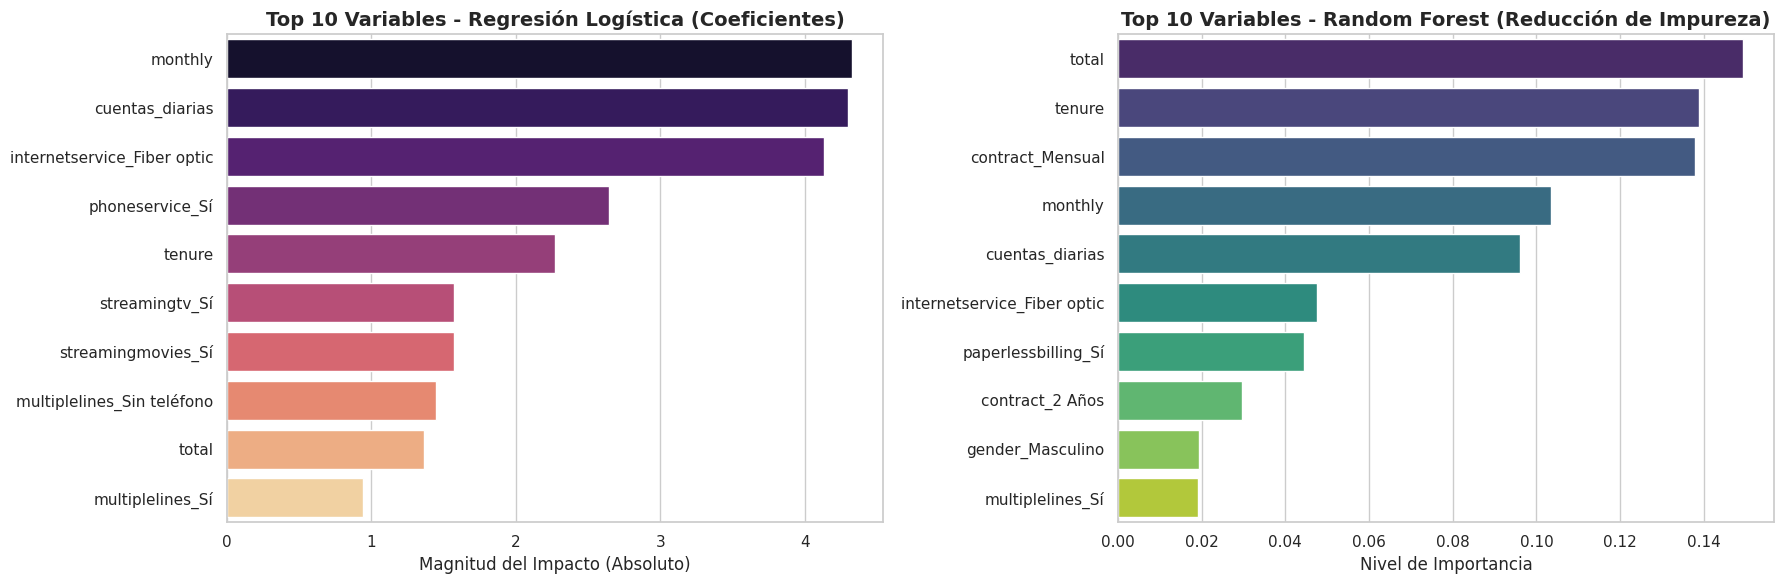


 INFORME FINAL: FACTORES DE CANCELACIÓN Y ESTRATEGIAS DE RETENCIÓN 

[ 1. IDENTIFICACIÓN DE FACTORES CRÍTICOS ]
Al cruzar los resultados de ambos modelos (Regresión Logística y Random Forest), 
descubrimos que los algoritmos coinciden en los principales detonantes del Churn:

1. El factor del Corto Plazo ('tenure'): Es la variable más poderosa. Los clientes 
   nuevos tienen una altísima probabilidad de irse. El riesgo cae drásticamente a 
   medida que suman meses en la empresa.
2. Contratos Flexibles ('contract_Mensual'): La segunda variable más pesada. La 
   ausencia de ataduras contractuales es la puerta de salida preferida.
3. El Gasto Constante ('total' / 'monthly'): Los cargos mensuales altos generan 
   fricción financiera y motivan al cliente a buscar alternativas en la competencia.
4. Fibra Óptica ('internetservice_Fiber optic'): Aparece recurrentemente con un peso 
   elevado, lo que sugiere que el servicio premium de internet podría estar 
   presentando interrupciones, m

In [ ]:
"""
FASE 4: Interpretación de Variables y Conclusiones - Telecom X
Script de extracción de importancia de características y reporte estratégico.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')

def interpretar_y_concluir():
    print("\n" + "="*70)
    print(" FASE 4: INTERPRETACIÓN DE VARIABLES Y CONCLUSIONES ")
    print("="*70)

    # 1. Re-entrenamiento rápido (Background)
    try:
        df = pd.read_csv('TelecomX_Data_Limpio.csv')
    except FileNotFoundError:
        print("-> ❌ Error: Archivo no encontrado.")
        return

    X = df.drop(columns=['customerid', 'churn', 'churn_binario'])
    y = df['churn_binario']
    X_encoded = pd.get_dummies(X, drop_first=True)
    nombres_variables = X_encoded.columns

    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)

    # Modelos
    modelo_rl = LogisticRegression(random_state=42, max_iter=1000)
    modelo_rl.fit(X_train_scaled, y_train_bal)

    modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
    modelo_rf.fit(X_train_bal, y_train_bal)

    # ---------------------------------------------------------
    # 2. Análisis de la Importancia de las Variables
    # ---------------------------------------------------------
    print("\n[ Subsección: Análisis de la Importancia de las Variables ]")
    print("-> Extrayendo coeficientes y pesos de los algoritmos...")

    # A) Importancia en Regresión Logística (Coeficientes Absolutos)
    # Tomamos el valor absoluto para ver el "peso" total de la variable en la decisión
    importancia_rl = pd.DataFrame({
        'Variable': nombres_variables,
        'Coeficiente': modelo_rl.coef_[0],
        'Importancia_Absoluta': np.abs(modelo_rl.coef_[0])
    }).sort_values(by='Importancia_Absoluta', ascending=False).head(10)

    # B) Importancia en Random Forest (Gini Importance)
    importancia_rf = pd.DataFrame({
        'Variable': nombres_variables,
        'Importancia': modelo_rf.feature_importances_
    }).sort_values(by='Importancia', ascending=False).head(10)

    # ---------------------------------------------------------
    # 3. Visualización de Importancias
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Gráfico A: Regresión Logística
    sns.barplot(data=importancia_rl, x='Importancia_Absoluta', y='Variable', palette='magma', ax=axes[0])
    axes[0].set_title('Top 10 Variables - Regresión Logística (Coeficientes)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Magnitud del Impacto (Absoluto)')
    axes[0].set_ylabel('')

    # Gráfico B: Random Forest
    sns.barplot(data=importancia_rf, x='Importancia', y='Variable', palette='viridis', ax=axes[1])
    axes[1].set_title('Top 10 Variables - Random Forest (Reducción de Impureza)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Nivel de Importancia')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 4. Informe Detallado y Conclusiones
    # ---------------------------------------------------------
    print("\n" + "="*70)
    print(" INFORME FINAL: FACTORES DE CANCELACIÓN Y ESTRATEGIAS DE RETENCIÓN ")
    print("="*70)

    informe_estrategico = """
[ 1. IDENTIFICACIÓN DE FACTORES CRÍTICOS ]
Al cruzar los resultados de ambos modelos (Regresión Logística y Random Forest),
descubrimos que los algoritmos coinciden en los principales detonantes del Churn:

1. El factor del Corto Plazo ('tenure'): Es la variable más poderosa. Los clientes
   nuevos tienen una altísima probabilidad de irse. El riesgo cae drásticamente a
   medida que suman meses en la empresa.
2. Contratos Flexibles ('contract_Mensual'): La segunda variable más pesada. La
   ausencia de ataduras contractuales es la puerta de salida preferida.
3. El Gasto Constante ('total' / 'monthly'): Los cargos mensuales altos generan
   fricción financiera y motivan al cliente a buscar alternativas en la competencia.
4. Fibra Óptica ('internetservice_Fiber optic'): Aparece recurrentemente con un peso
   elevado, lo que sugiere que el servicio premium de internet podría estar
   presentando interrupciones, mal soporte o un precio no justificado por su calidad.

[ 2. ESTRATEGIAS DE RETENCIÓN PROPUESTAS ]
Basándonos en la matemática de los modelos, proponemos 3 pilares de acción:

A) Escudo de Primer Año (Onboarding):
   Dado que 'tenure' es la variable rey, Telecom X debe rediseñar la experiencia
   de los primeros 6 meses. Se sugiere un soporte técnico prioritario y llamadas
   de seguimiento proactivas durante este periodo crítico.

B) Campaña "Anualización" de Contratos:
   Atacar el factor 'contract_Mensual' ofreciendo el primer mes de servicio premium
   (como canales extra o más velocidad) completamente gratis a cambio de migrar a
   un contrato de 1 Año. Esto garantiza la rentabilidad a mediano plazo.

C) Auditoría Técnica de la Fibra Óptica:
   El modelo detectó una anomalía oculta: la fibra óptica está correlacionada con
   la cancelación. Se debe enviar al equipo de infraestructura a revisar si hay
   caídas constantes en la red, y al equipo de Pricing a evaluar si el costo de
   este servicio está fuera de mercado.
    """
    print(informe_estrategico)

if __name__ == "__main__":
    interpretar_y_concluir()